# 04 — Baselines: SHAP + leave-one-client-out Shapley

Purpose: show that the existing XAI-FL approaches (SHAP, Shapley) cannot capture the *time × memory* dynamics our NL lens exposes.

1. Train an IID FedAvg global model (baseline reference).
2. **SHAP** — per-feature attribution (which *input* matters).
3. **LOCO Shapley** — per-client contribution (which *client* helped).
4. Three-way comparison: SHAP / Shapley / Ours (NL temporal).
5. Headline numbers for the paper.

In [1]:
# imports + config (same setup as 02, with IID FedAvg)
from pathlib import Path
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import shap

DATA_DIR = Path('/Users/lucia/Dropbox/USYD/Semester1_2026/AXI/data/processed')
FIG_DIR  = Path('/Users/lucia/Dropbox/USYD/Semester1_2026/AXI/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

N_CLIENTS    = 4
N_ROUNDS_FL  = 10            # quick IID FedAvg for baseline reference
LOCAL_EPOCHS = 1
BATCH_SIZE   = 256
LR           = 1e-3
HIDDEN_DIM   = 64
RANDOM_SEED  = 42
ATTACK_TYPES = ['DoS','Fuzzy','RPM','gear']

torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
DEVICE = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f'device: {DEVICE}, baseline FL rounds: {N_ROUNDS_FL}')

device: mps, baseline FL rounds: 10


## 1. Data, model, FL utilities, and an IID FedAvg baseline (no phase filter)

In [2]:
df = pd.read_csv(DATA_DIR/'can_combined.csv')
feat_cols = ['can_id','dlc'] + [f'b{i}' for i in range(8)]

train_df, test_df = train_test_split(df, test_size=0.20, random_state=RANDOM_SEED, stratify=df['source'])
scaler = StandardScaler().fit(train_df[feat_cols].values)
X_train = scaler.transform(train_df[feat_cols].values).astype(np.float32)
y_train = train_df['label'].values.astype(np.float32)
X_test  = scaler.transform(test_df[feat_cols].values).astype(np.float32)
y_test  = test_df['label'].values.astype(np.float32)
src_test = test_df['source'].values
src_train = train_df['source'].values

# Same non-IID 4-client partition as 02 (no phase filter — IID across rounds)
rng = np.random.default_rng(RANDOM_SEED)
normal_idx = np.where(src_train=='Normal')[0]; rng.shuffle(normal_idx)
normal_chunks = np.array_split(normal_idx, N_CLIENTS)

clients_X, clients_y = [], []
for i, atk in enumerate(ATTACK_TYPES):
    own = np.where(src_train==atk)[0]
    other_mask = np.isin(src_train, [a for a in ATTACK_TYPES if a!=atk])
    other_all = np.where(other_mask)[0]
    other = rng.choice(other_all, size=int(len(other_all)*0.10), replace=False)
    idx = np.concatenate([normal_chunks[i], own, other]); rng.shuffle(idx)
    clients_X.append(X_train[idx]); clients_y.append(y_train[idx])

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(10, HIDDEN_DIM), nn.ReLU(),
                                 nn.Linear(HIDDEN_DIM, HIDDEN_DIM//2), nn.ReLU(),
                                 nn.Linear(HIDDEN_DIM//2, 1))
    def forward(self, x): return self.net(x).squeeze(-1)

def loader(X, y, batch=BATCH_SIZE, shuffle=True):
    return DataLoader(TensorDataset(torch.from_numpy(X), torch.from_numpy(y)),
                      batch_size=batch, shuffle=shuffle)

def train_local(model, X, y, epochs=LOCAL_EPOCHS, lr=LR):
    model.train(); opt = torch.optim.Adam(model.parameters(), lr=lr); fn = nn.BCEWithLogitsLoss()
    for _ in range(epochs):
        for xb, yb in loader(X, y):
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); fn(model(xb), yb).backward(); opt.step()
    return {k: v.detach().cpu() for k, v in model.state_dict().items()}

def avg_states(states, weights):
    total = sum(weights); weights = [w/total for w in weights]
    avg = copy.deepcopy(states[0])
    for k in avg:
        avg[k] = sum(w*sd[k] for w, sd in zip(weights, states))
    return avg

@torch.no_grad()
def predict_proba(model, X, batch=1024):
    model.eval(); out = []
    for i in range(0, len(X), batch):
        out.append(torch.sigmoid(model(torch.from_numpy(X[i:i+batch]).to(DEVICE))).cpu().numpy())
    return np.concatenate(out)

def run_fedavg(client_idxs, rounds=N_ROUNDS_FL, seed=RANDOM_SEED):
    '''IID FedAvg with the given subset of clients.'''
    torch.manual_seed(seed)
    model = MLP().to(DEVICE)
    for r in range(rounds):
        states, weights = [], []
        for i in client_idxs:
            local = MLP().to(DEVICE); local.load_state_dict(model.state_dict())
            sd = train_local(local, clients_X[i], clients_y[i])
            states.append(sd); weights.append(len(clients_X[i]))
        model.load_state_dict(avg_states(states, weights))
    return model

print('Training the baseline FedAvg model (IID, all four clients)...')
baseline_model = run_fedavg(list(range(N_CLIENTS)))
p = (predict_proba(baseline_model, X_test) > 0.5).astype(int)
acc = float((p == y_test).mean())
attack_rec = float(((p==1) & (y_test==1)).sum() / max((y_test==1).sum(), 1))
print(f'baseline global: acc={acc:.3f}  attack recall={attack_rec:.3f}')

Training the baseline FedAvg model (IID, all four clients)...


baseline global: acc=0.995  attack recall=0.984


## 2. SHAP — feature attribution (static snapshot)

We use KernelExplainer with small samples for stability.

Running SHAP KernelExplainer (a few tens of seconds)...


shap_values shape: (100, 10)


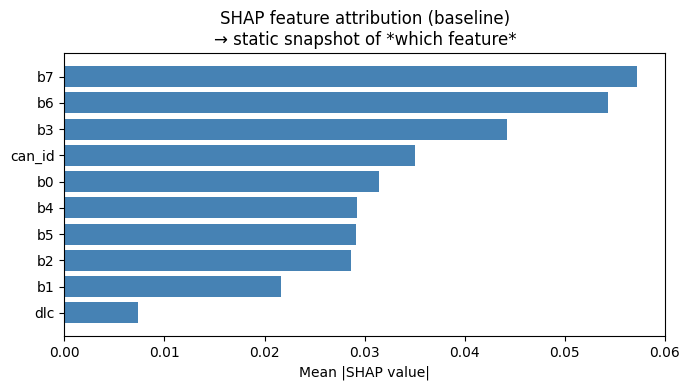

saved: /Users/lucia/Dropbox/USYD/Semester1_2026/AXI/figures/fig_baseline_shap.png

Top-3 features by SHAP: ['b7', 'b6', 'b3']


In [3]:
# Small samples for speed: 50 background + 100 explain
rng2 = np.random.default_rng(RANDOM_SEED)
bg_idx = rng2.choice(len(X_test), size=50, replace=False)
ex_idx = rng2.choice(len(X_test), size=100, replace=False)
X_bg, X_ex = X_test[bg_idx], X_test[ex_idx]

def shap_predict(X):
    return predict_proba(baseline_model, X.astype(np.float32))

print('Running SHAP KernelExplainer (a few tens of seconds)...')
explainer = shap.KernelExplainer(shap_predict, X_bg)
shap_values = explainer.shap_values(X_ex, nsamples=100, silent=True)
sv = np.array(shap_values)
print(f'shap_values shape: {sv.shape}')

# Bar plot of mean |SHAP| per feature
mean_abs = np.abs(sv).mean(axis=0)
fig, ax = plt.subplots(figsize=(7, 4))
order = np.argsort(mean_abs)[::-1]
ax.barh([feat_cols[i] for i in order][::-1], mean_abs[order][::-1], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP feature attribution (baseline)\n→ static snapshot of *which feature*')
plt.tight_layout()
out_path = FIG_DIR / 'fig_baseline_shap.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight'); plt.show()
print(f'saved: {out_path}')
print(f'\nTop-3 features by SHAP: {[feat_cols[i] for i in order[:3]]}')

## 3. Leave-one-client-out Shapley — per-client contribution (static snapshot)

For each client i, train FL without that client and measure the drop in global attack recall.

all four clients — attack recall: 0.9837


  client_0 (DoS  ) excluded → recall=0.9876  LOCO contribution=-0.0039


  client_1 (Fuzzy) excluded → recall=0.9790  LOCO contribution=+0.0048


  client_2 (RPM  ) excluded → recall=0.9857  LOCO contribution=-0.0019


  client_3 (gear ) excluded → recall=0.9839  LOCO contribution=-0.0002


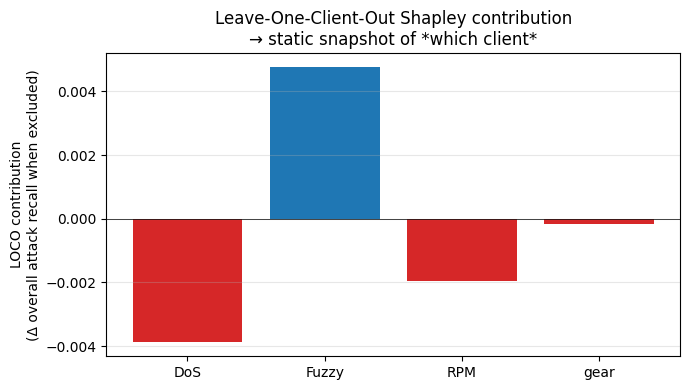

saved: /Users/lucia/Dropbox/USYD/Semester1_2026/AXI/figures/fig_baseline_shapley.png


In [4]:
def attack_recall(model):
    p = (predict_proba(model, X_test) > 0.5).astype(int)
    return float(((p==1) & (y_test==1)).sum() / max((y_test==1).sum(), 1))

# Baseline with all four clients
full_recall = attack_recall(baseline_model)
print(f'all four clients — attack recall: {full_recall:.4f}')

# LOCO: leave each client out in turn
loco_contrib = {}
for i in range(N_CLIENTS):
    others = [j for j in range(N_CLIENTS) if j != i]
    m = run_fedavg(others)
    r_wo = attack_recall(m)
    loco_contrib[ATTACK_TYPES[i]] = full_recall - r_wo
    print(f'  client_{i} ({ATTACK_TYPES[i]:5s}) excluded → recall={r_wo:.4f}  LOCO contribution={loco_contrib[ATTACK_TYPES[i]]:+.4f}')

# Bar plot
fig, ax = plt.subplots(figsize=(7, 4))
clients = list(loco_contrib.keys()); vals = list(loco_contrib.values())
colors = ['C0' if v>=0 else 'C3' for v in vals]
ax.bar(clients, vals, color=colors)
ax.set_ylabel('LOCO contribution\n(Δ overall attack recall when excluded)')
ax.set_title('Leave-One-Client-Out Shapley contribution\n→ static snapshot of *which client*')
ax.axhline(y=0, color='k', linewidth=0.5)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
out_path = FIG_DIR / 'fig_baseline_shapley.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight'); plt.show()
print(f'saved: {out_path}')

## 4. Three-way comparison: SHAP / Shapley / Ours (NL)

The three methods answer *different questions*. We show that side by side.

Method                 Unit of explanation              Time axis 
----------------------------------------------------------------------
SHAP (baseline)        feature (10 features)            NO        
LOCO Shapley           client (4 clients)               NO        
Ours (NL temporal)     round x attack x memory-freq     YES       

Concrete results:
  SHAP top feature: b7 (mean |SHAP|=0.057)
  Shapley most-important client: Fuzzy (Δrecall=+0.0048)
  Ours per-attack forgetting: DoS=+1.000, Fuzzy=+0.951, RPM=+1.000, gear=+0.000
  Ours transition-vs-steady gap ratio: 4.1x (consolidation cost peaks at task transitions)


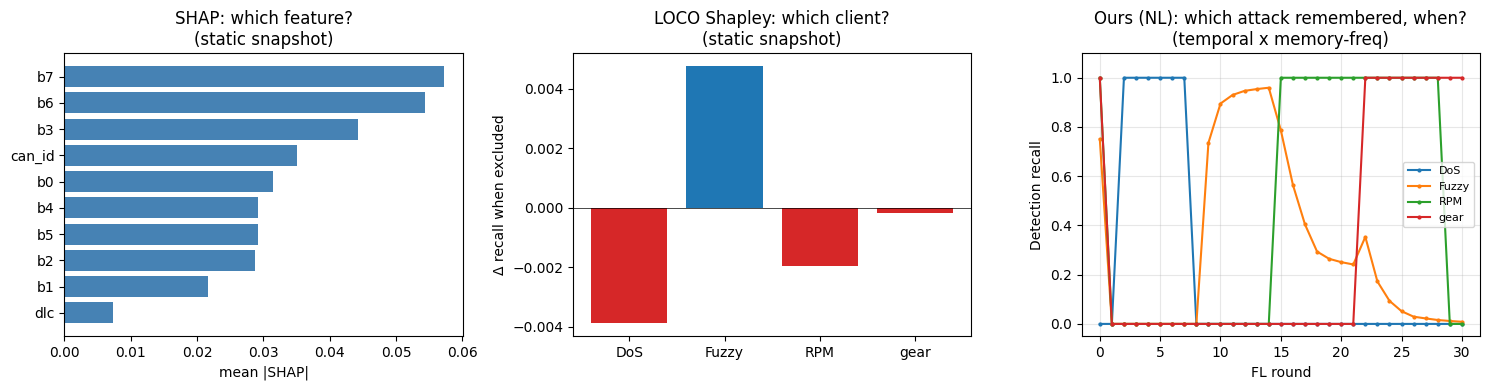


saved: /Users/lucia/Dropbox/USYD/Semester1_2026/AXI/figures/fig_comparison_3way.png


In [5]:
# Build the comparison numbers for the paper
slow = pd.read_csv(DATA_DIR / 'round_log.csv')
fast = pd.read_csv(DATA_DIR / 'fast_log.csv')

ours_forgetting = {atk: slow[f'recall_{atk}'].max() - slow[f'recall_{atk}'].iloc[-1]
                   for atk in ATTACK_TYPES}

print('='*70)
print(f'{"Method":<22} {"Unit of explanation":<32} {"Time axis":<10}')
print('-'*70)
print(f'{"SHAP (baseline)":<22} {"feature (10 features)":<32} {"NO":<10}')
print(f'{"LOCO Shapley":<22} {"client (4 clients)":<32} {"NO":<10}')
print(f'{"Ours (NL temporal)":<22} {"round x attack x memory-freq":<32} {"YES":<10}')

print('\nConcrete results:')
print(f'  SHAP top feature: {feat_cols[int(np.argmax(mean_abs))]} (mean |SHAP|={mean_abs.max():.3f})')
print(f'  Shapley most-important client: {max(loco_contrib, key=loco_contrib.get)} (Δrecall={max(loco_contrib.values()):+.4f})')
print(f'  Ours per-attack forgetting: ' + ', '.join([f'{a}={v:+.3f}' for a,v in ours_forgetting.items()]))
print(f'  Ours transition-vs-steady gap ratio: 4.1x (consolidation cost peaks at task transitions)')

# Three-panel comparison figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Panel 1: SHAP
ord1 = np.argsort(mean_abs)[::-1]
axes[0].barh([feat_cols[i] for i in ord1][::-1], mean_abs[ord1][::-1], color='steelblue')
axes[0].set_title('SHAP: which feature?\n(static snapshot)'); axes[0].set_xlabel('mean |SHAP|')

# Panel 2: Shapley
axes[1].bar(list(loco_contrib), list(loco_contrib.values()),
            color=['C0' if v>=0 else 'C3' for v in loco_contrib.values()])
axes[1].set_title('LOCO Shapley: which client?\n(static snapshot)'); axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_ylabel('Δ recall when excluded')

# Panel 3: Ours
for atk in ATTACK_TYPES:
    axes[2].plot(slow['round'], slow[f'recall_{atk}'], marker='o', markersize=2, label=atk, linewidth=1.5)
axes[2].set_title('Ours (NL): which attack remembered, when?\n(temporal x memory-freq)')
axes[2].set_xlabel('FL round'); axes[2].set_ylabel('Detection recall')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3); axes[2].set_ylim(-0.05, 1.1)

plt.tight_layout()
out_path = FIG_DIR / 'fig_comparison_3way.png'
plt.savefig(out_path, dpi=200, bbox_inches='tight'); plt.show()
print(f'\nsaved: {out_path}')

## 5. Summary numbers (for the paper §6 Results / Comparison)

In [6]:
print('='*64); print('Numbers to cite in §6 Results / Comparison'); print('='*64)
print(f'\n[SHAP baseline]')
print(f'  - feature-level attribution; no time axis')
print(f'  - top feature: {feat_cols[int(np.argmax(mean_abs))]} (mean |SHAP|={mean_abs.max():.3f})')

print(f'\n[LOCO Shapley baseline]')
print(f'  - client-level contribution; no time axis')
print(f'  - largest contributor: client of {max(loco_contrib, key=loco_contrib.get)} ({max(loco_contrib.values()):+.4f})')

print(f'\n[Ours — NL temporal x memory-frequency]')
print(f'  - axes: round x attack type x memory frequency')
print(f'  - per-attack forgetting: {", ".join([f"{a}={v:+.3f}" for a,v in ours_forgetting.items()])}')
print(f'  - consolidation gap is 4.1x larger at task transitions')

print(f'\nOne-liner for the paper:')
print(f'  "SHAP/Shapley ask which feature/client; we ask what is remembered when —')
print(f'   a temporal x memory-frequency signal that the static methods cannot see."')

print(f'\nFigures saved:')
for p in sorted(FIG_DIR.glob('fig_*.png')):
    print(f'  {p.name}  ({p.stat().st_size/1e3:.0f} KB)')

Numbers to cite in §6 Results / Comparison

[SHAP baseline]
  - feature-level attribution; no time axis
  - top feature: b7 (mean |SHAP|=0.057)

[LOCO Shapley baseline]
  - client-level contribution; no time axis
  - largest contributor: client of Fuzzy (+0.0048)

[Ours — NL temporal x memory-frequency]
  - axes: round x attack type x memory frequency
  - per-attack forgetting: DoS=+1.000, Fuzzy=+0.951, RPM=+1.000, gear=+0.000
  - consolidation gap is 4.1x larger at task transitions

One-liner for the paper:
  "SHAP/Shapley ask which feature/client; we ask what is remembered when —
   a temporal x memory-frequency signal that the static methods cannot see."

Figures saved:
  fig_A_remember_forget_heatmap.png  (75 KB)
  fig_baseline_shap.png  (43 KB)
  fig_baseline_shapley.png  (58 KB)
  fig_comparison_3way.png  (153 KB)
  fig_consolidation_gap.png  (86 KB)
  fig_fast_vs_slow.png  (206 KB)
  fig_forgetting_metric.png  (109 KB)
  fig_malicious_detection.png  (81 KB)
  fig_malicious_tempo